# Question 2 — Classification
Using Decision Trees to classify whether a song would be liked by Sriharsha or Janya.

A song is considered **liked** if the user has listened to it for a combined total of **10+ minutes** across all plays. Features are drawn from the audio feature cache in .

In [1]:
import os
os.chdir('/Users/muadshaikh/Spotify-Wrapped')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='darkgrid')

## 1. Load Data

In [2]:
def load_user(folder):
    records = []
    for i in range(5):
        try:
            records += json.load(open(f'public/{folder}/StreamingHistory_music_{i}.json', encoding='utf-8'))
        except FileNotFoundError:
            break
    df = pd.DataFrame(records)
    df = df[df['msPlayed'] >= 5000].copy()
    df['minutes'] = df['msPlayed'] / 60000
    df['track_key'] = df['trackName'] + ' | ' + df['artistName']
    return df

sri = load_user('s')
jan = load_user('j')
track_info = json.load(open('public/track_info.json', encoding='utf-8'))

AUDIO_FEATURES = ['energy', 'danceability', 'happiness', 'acousticness',
                  'instrumentalness', 'liveness', 'speechiness', 'tempo', 'popularity']

print(f'Sriharsha: {len(sri):,} plays | Janya: {len(jan):,} plays')
print(f'Track info cache: {len(track_info):,} tracks')

Sriharsha: 10,422 plays | Janya: 14,153 plays
Track info cache: 6,591 tracks


## 2. Build Labeled Dataset

In [3]:
def build_dataset(df, liked_threshold=10):
    track_mins = df.groupby('track_key')['minutes'].sum()
    rows = []
    for track_key, total_mins in track_mins.items():
        info = track_info.get(track_key)
        if info:
            feat = {f: info.get(f) for f in AUDIO_FEATURES}
            if all(v is not None for v in feat.values()):
                feat['liked'] = int(total_mins >= liked_threshold)
                rows.append(feat)
    return pd.DataFrame(rows)

sri_df = build_dataset(sri)
jan_df = build_dataset(jan)

print(f'Sri  — total: {len(sri_df):,} | liked: {sri_df["liked"].sum():,} ({100*sri_df["liked"].mean():.1f}%)')
print(f'Janya — total: {len(jan_df):,} | liked: {jan_df["liked"].sum():,} ({100*jan_df["liked"].mean():.1f}%)')

Sri  — total: 2,889 | liked: 752 (26.0%)
Janya — total: 3,243 | liked: 432 (13.3%)


## 3. Train Decision Trees

=== Sriharsha ===
              precision    recall  f1-score   support

   Not Liked       0.74      0.99      0.85       428
       Liked       0.00      0.00      0.00       150

    accuracy                           0.73       578
   macro avg       0.37      0.50      0.42       578
weighted avg       0.55      0.73      0.63       578



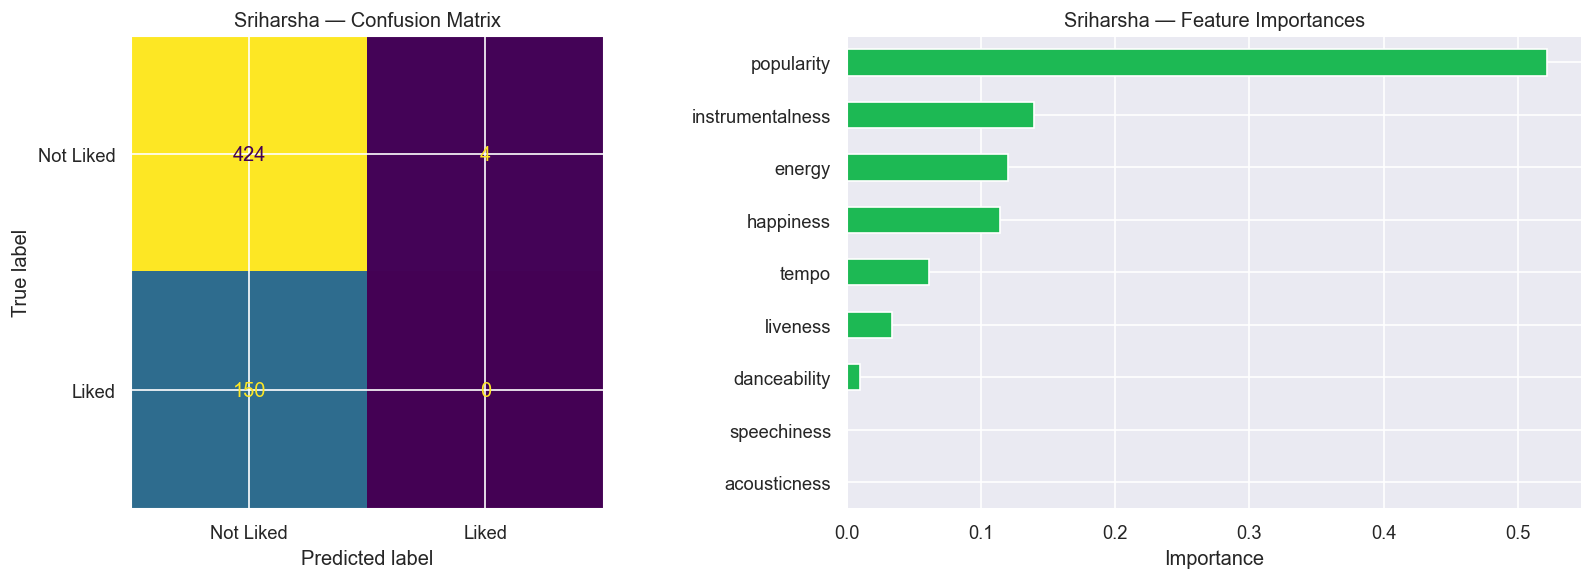

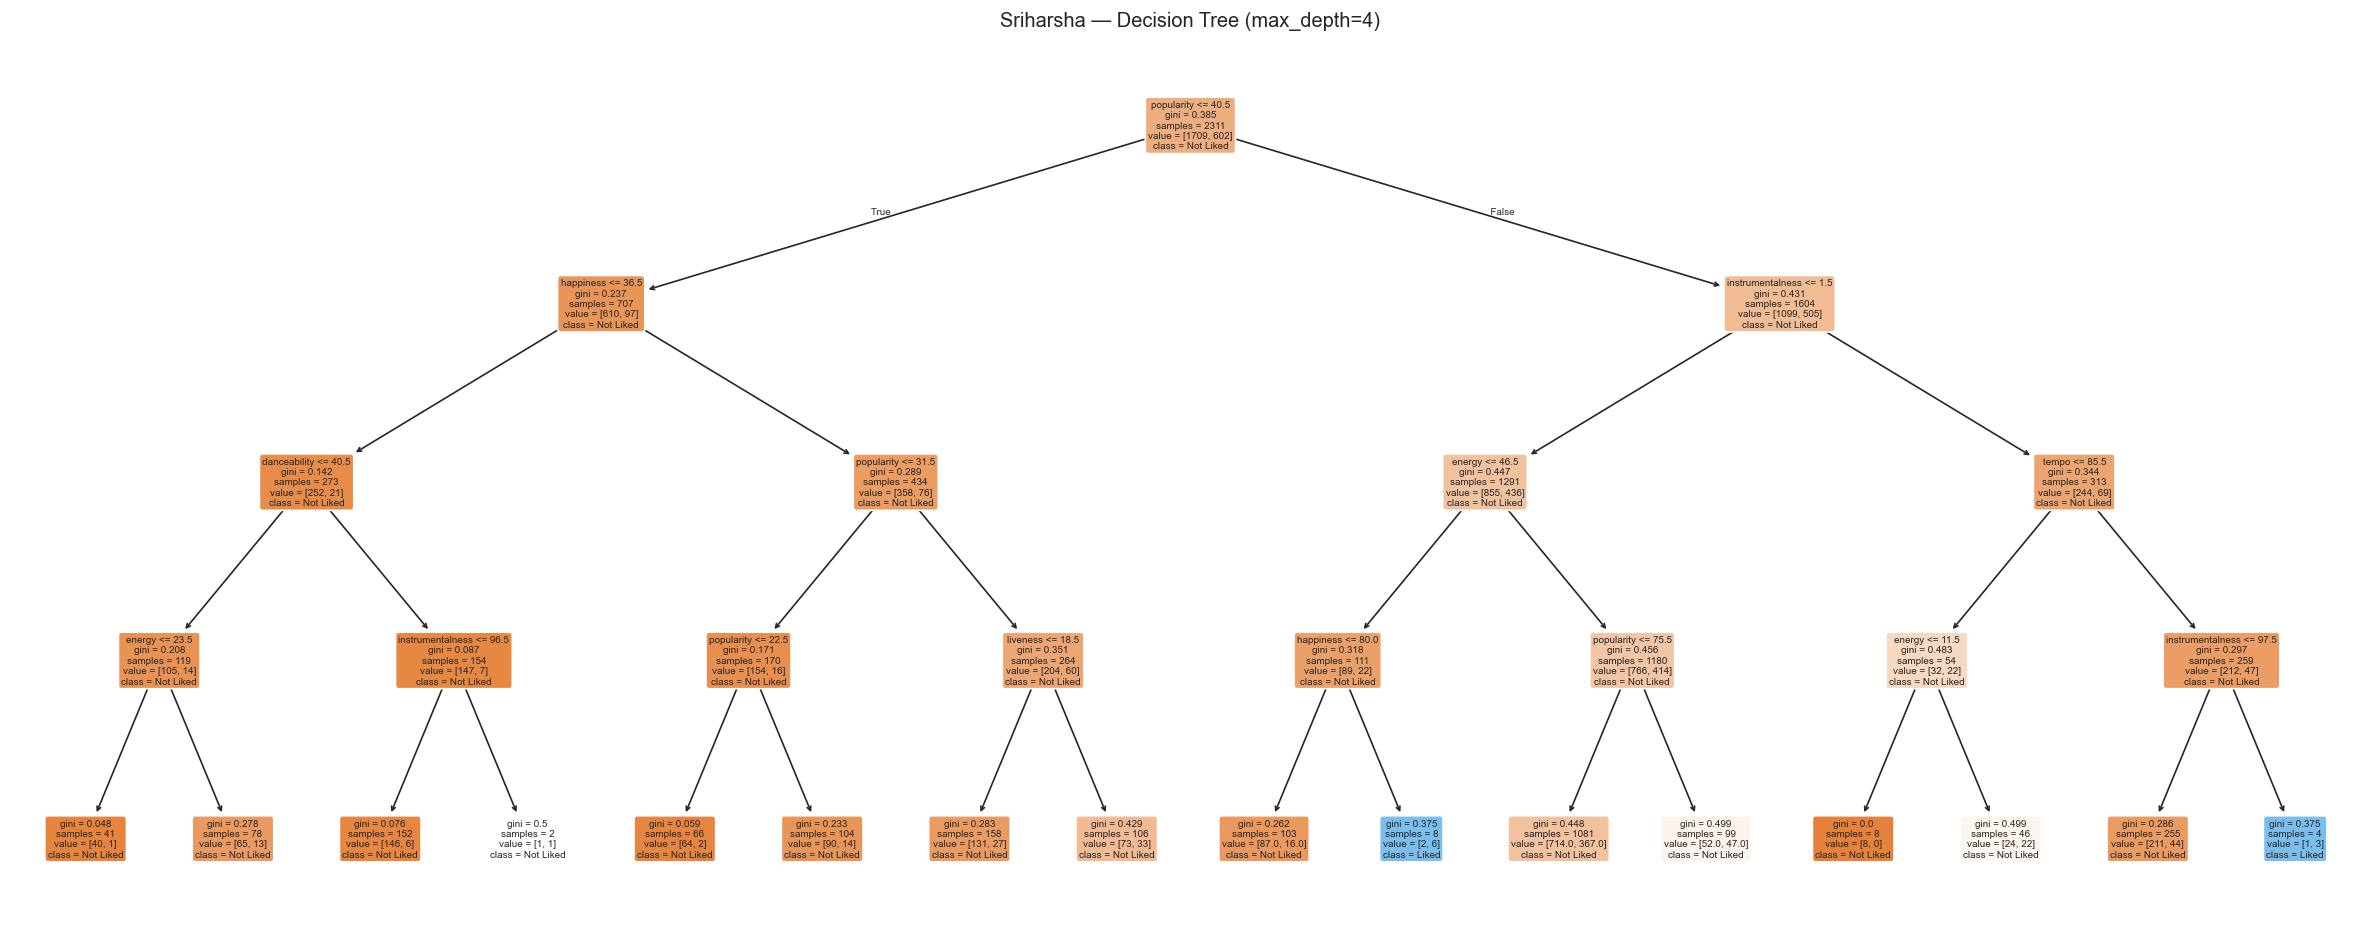

=== Janya ===
              precision    recall  f1-score   support

   Not Liked       0.87      0.99      0.93       563
       Liked       0.00      0.00      0.00        86

    accuracy                           0.86       649
   macro avg       0.43      0.50      0.46       649
weighted avg       0.75      0.86      0.80       649



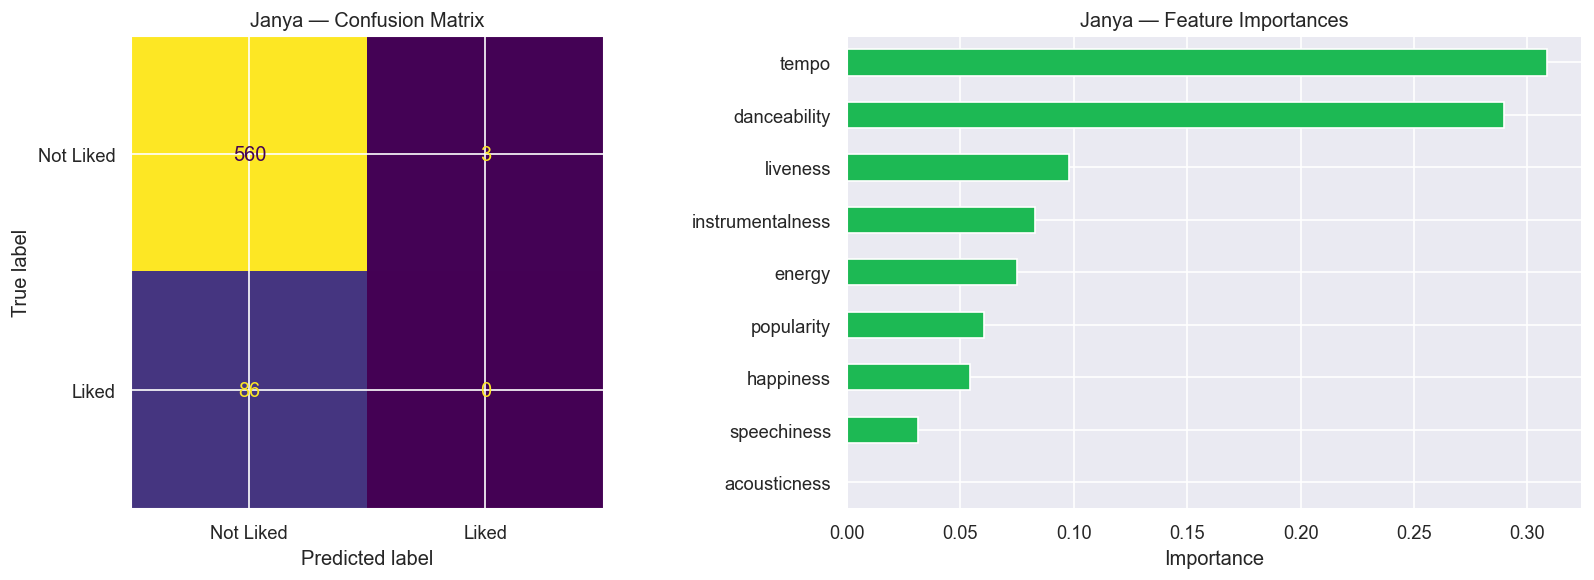

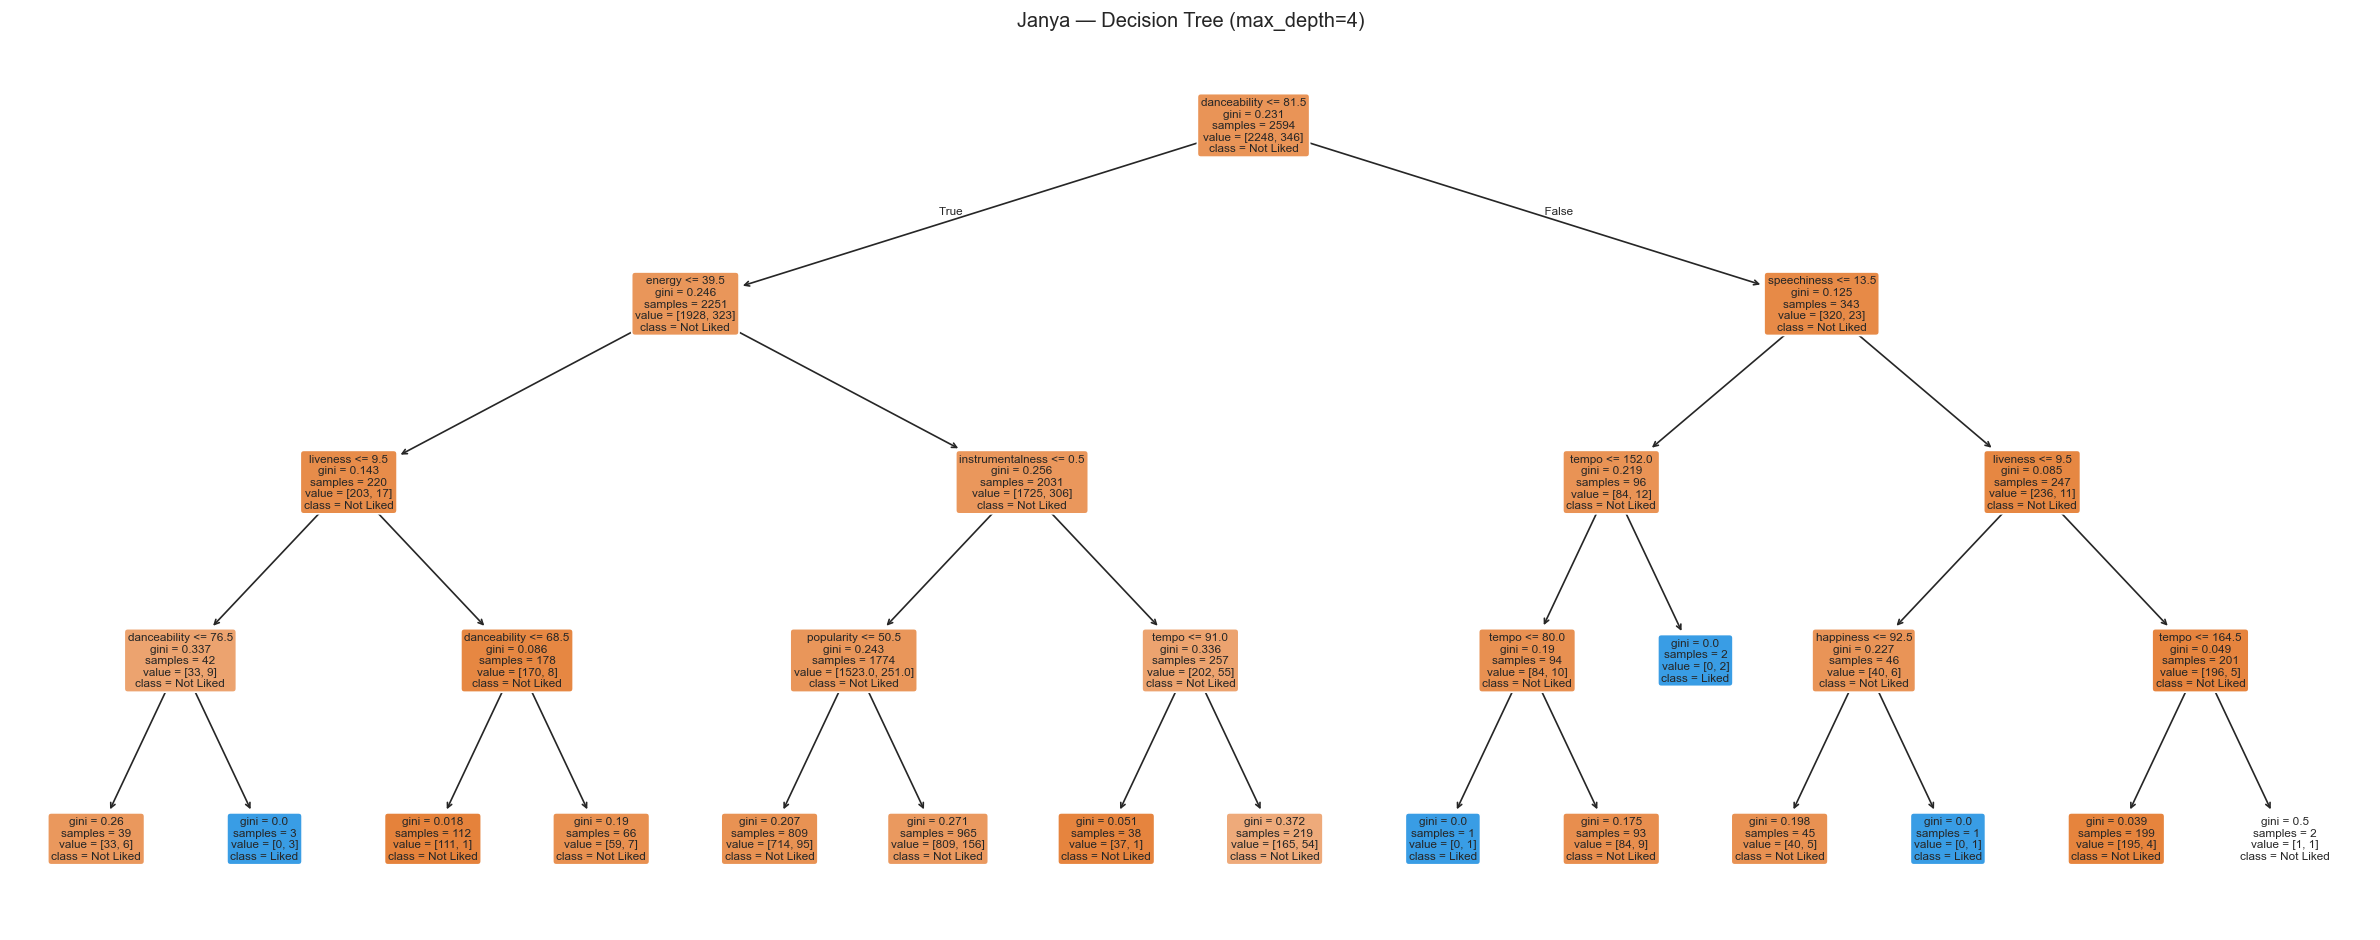

In [5]:
def train_tree(df, name):
    X = df[AUDIO_FEATURES]
    y = df['liked']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    clf = DecisionTreeClassifier(max_depth=4, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    print(f'=== {name} ===')
    print(classification_report(y_test, y_pred, target_names=['Not Liked', 'Liked']))

    # Confusion matrix
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=['Not Liked', 'Liked']).plot(ax=axes[0], colorbar=False)
    axes[0].set_title(f'{name} — Confusion Matrix')

    # Feature importance
    importances = pd.Series(clf.feature_importances_, index=AUDIO_FEATURES).sort_values(ascending=True)
    importances.plot(kind='barh', ax=axes[1], color='#1DB954')
    axes[1].set_title(f'{name} — Feature Importances')
    axes[1].set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

    # Decision tree plot
    fig, ax = plt.subplots(figsize=(20, 8))
    plot_tree(clf, feature_names=AUDIO_FEATURES, class_names=['Not Liked', 'Liked'],
              filled=True, rounded=True, ax=ax)
    plt.title(f'{name} — Decision Tree (max_depth=4)')
    plt.tight_layout()
    plt.show()

    return clf

sri_clf  = train_tree(sri_df,  'Sriharsha')
jan_clf  = train_tree(jan_df,  'Janya')